# 02 - Delta Hedging Backtest

This notebook reruns the baseline synthetic hedging experiment from scratch.

The key cleanup relative to the exploratory notebooks is that the constant and regime hedges are compared on a **common premium basis**. That removes spurious differences caused by each model charging a different initial option price.

We also label the regime hedge clearly as an **oracle benchmark**, because it uses the true simulated regime state at each rebalance date.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


def find_project_root() -> Path:
    current = Path.cwd().resolve()
    for candidate in [current, *current.parents]:
        if (candidate / ".git").exists():
            return candidate
    raise FileNotFoundError("Could not locate the project root from the current working directory.")


PROJECT_ROOT = find_project_root()
ANALYSIS_DIR = PROJECT_ROOT / "data" / "synthetic_consolidated"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
SCRIPTS_DIR = PROJECT_ROOT / "scripts"
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from synthetic_analysis_utils import (
    TRADING_DAYS_PER_YEAR,
    average_off_diagonal,
    basket_call_payoff,
    basket_values,
    build_transition_matrix,
    empirical_return_correlation,
    equicorrelation_matrix,
    evaluate_hedger,
    initial_hedge_from_model,
    monte_carlo_price_summary,
    pnl_summary,
    simulate_constant_paths,
    simulate_regime_switching_paths,
    summary_frame_from_results,
    unhedged_short_pnl,
)

In [2]:
asset_names = np.array(["Asset 1", "Asset 2", "Asset 3"])
spot = np.array([100.0, 95.0, 110.0])
weights = np.array([0.40, 0.35, 0.25])
vol = np.array([0.20, 0.25, 0.22])
div_yield = np.zeros_like(spot)
strike = float(weights @ spot)

rate = 0.03
maturity = 1.0
hedge_steps = 12
hedge_dt = maturity / hedge_steps
days_per_hedge_step = TRADING_DAYS_PER_YEAR // hedge_steps

rho_constant_level = 0.35
rho_calm_level = 0.20
rho_stress_level = 0.75
p01_daily = 0.03
p10_daily = 0.12
start_regime = 0

n_true_world_paths = 300
delta_mc_paths = 2000
initial_price_mc_paths = 20000
bump_fraction = 0.01

corr_constant = equicorrelation_matrix(len(spot), rho_constant_level)
corr_calm = equicorrelation_matrix(len(spot), rho_calm_level)
corr_stress = equicorrelation_matrix(len(spot), rho_stress_level)
transition_daily = build_transition_matrix(p01_daily, p10_daily)
transition_hedge = np.linalg.matrix_power(transition_daily, days_per_hedge_step)

pricing_inputs = {
    "spot": spot,
    "weights": weights,
    "strike": strike,
    "rate": rate,
    "div_yield": div_yield,
    "vol": vol,
    "maturity": maturity,
    "hedge_steps": hedge_steps,
    "hedge_dt": hedge_dt,
    "delta_mc_paths": delta_mc_paths,
    "initial_price_mc_paths": initial_price_mc_paths,
    "bump_fraction": bump_fraction,
    "chol_constant": np.linalg.cholesky(corr_constant),
    "chol_calm": np.linalg.cholesky(corr_calm),
    "chol_stress": np.linalg.cholesky(corr_stress),
    "transition_hedge": transition_hedge,
    "start_regime": start_regime,
}

config = pd.DataFrame(
    [
        {"parameter": "true_world_paths", "value": n_true_world_paths},
        {"parameter": "delta_mc_paths", "value": delta_mc_paths},
        {"parameter": "initial_price_mc_paths", "value": initial_price_mc_paths},
        {"parameter": "hedge_steps", "value": hedge_steps},
        {"parameter": "days_per_hedge_step", "value": days_per_hedge_step},
        {"parameter": "bump_fraction", "value": bump_fraction},
    ]
)
display(config)

,parameter,value
0,true_world_paths,300.0000
1,delta_mc_paths,"2,000.0000"
2,initial_price_mc_paths,"20,000.0000"
3,hedge_steps,12.0000
4,days_per_hedge_step,21.0000
5,bump_fraction,0.0100


In [3]:
true_paths, true_regimes = simulate_regime_switching_paths(
    spot=spot,
    rate=rate,
    div_yield=div_yield,
    vol=vol,
    maturity=maturity,
    n_steps=hedge_steps,
    n_paths=n_true_world_paths,
    corr_calm=corr_calm,
    corr_stress=corr_stress,
    transition_matrix=transition_hedge,
    start_regime=start_regime,
    seed=2026,
)

constant_initial_price, constant_initial_delta = initial_hedge_from_model("constant", pricing_inputs, 4000)
regime_initial_price, regime_initial_delta = initial_hedge_from_model("regime", pricing_inputs, 5000)
regime_reference_price = regime_initial_price

initial_hedge_table = pd.DataFrame(
    [
        {
            "strategy": "Constant-correlation hedge",
            "model_initial_price": constant_initial_price,
            **{f"delta_{name}": value for name, value in zip(asset_names, constant_initial_delta)},
        },
        {
            "strategy": "Regime-switching hedge (oracle)",
            "model_initial_price": regime_initial_price,
            **{f"delta_{name}": value for name, value in zip(asset_names, regime_initial_delta)},
        },
    ]
)
initial_hedge_table.to_csv(ANALYSIS_DIR / "baseline_initial_hedge_table.csv", index=False)
display(Markdown("## Initial hedge estimates"))
display(initial_hedge_table.round(4))

## Initial hedge estimates

,strategy,model_initial_price,delta_Asset 1,delta_Asset 2,delta_Asset 3
0,Constant-correlation hedge,8.2181,0.2389,0.2146,0.1485
1,Regime-switching hedge (oracle),8.1026,0.2415,0.2177,0.1508


In [4]:
terminal_payoff = basket_call_payoff(true_paths[:, -1, :], weights, strike)
stress_fraction = true_regimes.mean(axis=1)

unhedged_clean_pnl = unhedged_short_pnl(
    terminal_payoff=terminal_payoff,
    rate=rate,
    maturity=maturity,
    funding_price=regime_reference_price,
)

constant_raw_summary, constant_raw_pnl, _ = evaluate_hedger(
    true_paths=true_paths,
    true_regimes=true_regimes,
    hedge_model="constant",
    pricing_inputs=pricing_inputs,
    base_seed=6000,
    funding_price=None,
)
regime_raw_summary, regime_raw_pnl, _ = evaluate_hedger(
    true_paths=true_paths,
    true_regimes=true_regimes,
    hedge_model="regime",
    pricing_inputs=pricing_inputs,
    base_seed=7000,
    funding_price=None,
)
constant_clean_summary, constant_clean_pnl, _ = evaluate_hedger(
    true_paths=true_paths,
    true_regimes=true_regimes,
    hedge_model="constant",
    pricing_inputs=pricing_inputs,
    base_seed=6000,
    funding_price=regime_reference_price,
)
regime_clean_summary, regime_clean_pnl, _ = evaluate_hedger(
    true_paths=true_paths,
    true_regimes=true_regimes,
    hedge_model="regime",
    pricing_inputs=pricing_inputs,
    base_seed=7000,
    funding_price=regime_reference_price,
)

raw_summary = pd.DataFrame(
    [
        {"strategy": "Constant-correlation hedge", **constant_raw_summary},
        {"strategy": "Regime-switching hedge (oracle)", **regime_raw_summary},
    ]
)
clean_summary = pd.DataFrame(
    [
        {
            "strategy": "Unhedged short option (regime premium basis)",
            "model_initial_price": regime_reference_price,
            "funding_initial_price": regime_reference_price,
            "premium_adjustment": 0.0,
            **pnl_summary(unhedged_clean_pnl),
        },
        {"strategy": "Constant-correlation hedge (regime premium basis)", **constant_clean_summary},
        {"strategy": "Regime-switching hedge (oracle, regime premium basis)", **regime_clean_summary},
    ]
)
clean_summary["std_reduction_vs_unhedged"] = 1.0 - clean_summary["std_pnl"] / clean_summary.loc[0, "std_pnl"]

clean_gap = pd.DataFrame(
    [
        {
            "comparison_basis": "Both hedges measured at regime initial premium",
            "premium_adjustment_to_regime": constant_clean_summary["premium_adjustment"],
            "std_gap_constant_minus_regime": constant_clean_summary["std_pnl"] - regime_clean_summary["std_pnl"],
            "q05_gap_regime_minus_constant": regime_clean_summary["q05_pnl"] - constant_clean_summary["q05_pnl"],
            "q01_gap_regime_minus_constant": regime_clean_summary["q01_pnl"] - constant_clean_summary["q01_pnl"],
            "mean_gap_regime_minus_constant": regime_clean_summary["mean_pnl"] - constant_clean_summary["mean_pnl"],
        }
    ]
)

pathwise_clean = pd.DataFrame(
    {
        "path_id": np.arange(n_true_world_paths),
        "stress_fraction": stress_fraction,
        "terminal_payoff": terminal_payoff,
        "unhedged_clean": unhedged_clean_pnl,
        "constant_clean": constant_clean_pnl,
        "regime_clean": regime_clean_pnl,
    }
)

raw_summary.to_csv(ANALYSIS_DIR / "baseline_hedging_summary_raw.csv", index=False)
clean_summary.to_csv(ANALYSIS_DIR / "baseline_hedging_summary_clean.csv", index=False)
clean_gap.to_csv(ANALYSIS_DIR / "baseline_hedging_clean_gap.csv", index=False)
pathwise_clean.to_csv(ANALYSIS_DIR / "baseline_pathwise_pnl_clean.csv", index=False)
config.to_csv(ANALYSIS_DIR / "baseline_hedging_config.csv", index=False)

display(Markdown("## Raw hedge summary"))
display(raw_summary.round(4))

display(Markdown("## Clean hedge comparison on a common premium basis"))
display(clean_summary.round(4))
display(clean_gap.round(4))

## Raw hedge summary

,strategy,runtime_seconds,model_initial_price,funding_initial_price,premium_adjustment,mean_pnl,std_pnl,median_pnl,q05_pnl,q01_pnl,min_pnl,max_pnl
0,Constant-correlation hedge,0.8628,8.0992,8.0992,0.0000,-0.0920,1.6793,-0.0415,-2.8923,-4.4964,-6.0305,4.5698
1,Regime-switching hedge (oracle),3.4010,8.0110,8.0110,0.0000,-0.1682,1.6398,-0.1274,-3.0744,-4.8994,-5.3761,4.5401


## Clean hedge comparison on a common premium basis

,strategy,model_initial_price,funding_initial_price,premium_adjustment,mean_pnl,std_pnl,median_pnl,q05_pnl,q01_pnl,min_pnl,max_pnl,runtime_seconds,std_reduction_vs_unhedged
0,Unhedged short option (regime premium basis),8.1026,8.1026,0.0000,0.1342,12.1372,7.3794,-26.2738,-37.2739,-56.1566,8.3494,NaN,0.0000
1,Constant-correlation hedge (regime premium basis),8.0992,8.1026,-0.0035,-0.0884,1.6793,-0.0380,-2.8887,-4.4929,-6.0269,4.5733,0.8194,0.8616
2,"Regime-switching hedge (oracle, regime premium...",8.0110,8.1026,-0.0917,-0.0737,1.6398,-0.0329,-2.9799,-4.8049,-5.2817,4.6346,3.4247,0.8649


,comparison_basis,premium_adjustment_to_regime,std_gap_constant_minus_regime,q05_gap_regime_minus_constant,q01_gap_regime_minus_constant,mean_gap_regime_minus_constant
0,Both hedges measured at regime initial premium,-0.0035,0.0395,-0.0912,-0.3120,0.0147


/var/folders/6n/xbpdfg2s7z5_z4t3j_8fzz7r0000gn/T/ipykernel_45133/2827359965.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[2].boxplot(


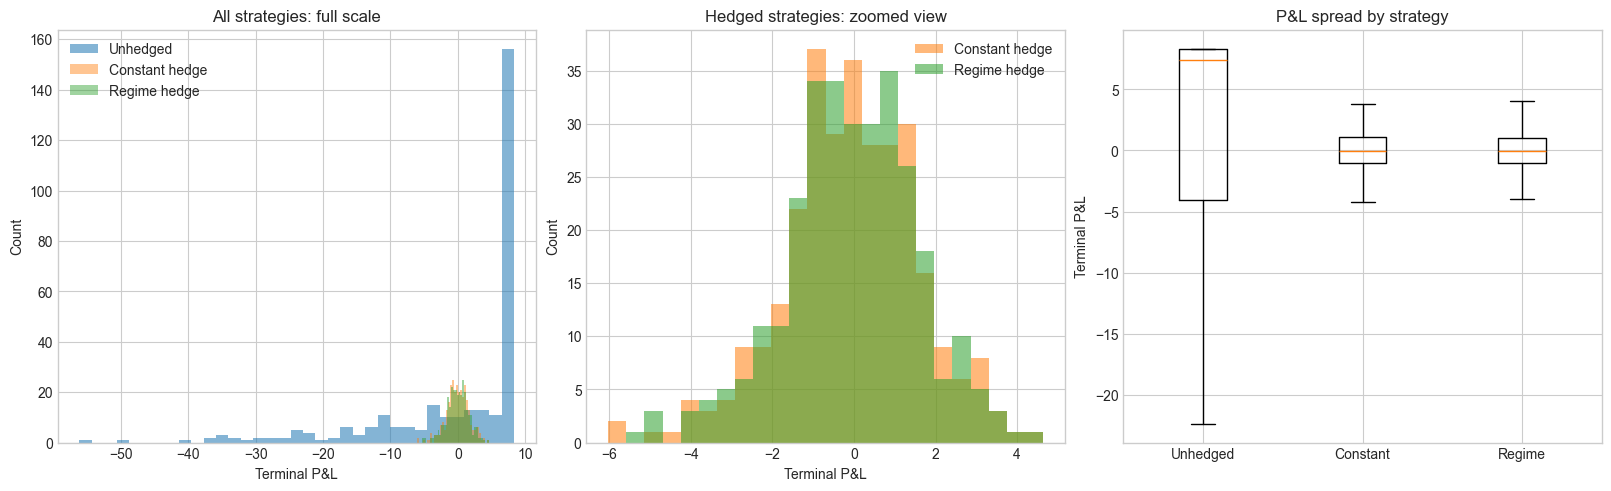

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.8), constrained_layout=True)

axes[0].hist(pathwise_clean["unhedged_clean"], bins=35, alpha=0.55, label="Unhedged", color="tab:blue")
axes[0].hist(pathwise_clean["constant_clean"], bins=35, alpha=0.45, label="Constant hedge", color="tab:orange")
axes[0].hist(pathwise_clean["regime_clean"], bins=35, alpha=0.45, label="Regime hedge", color="tab:green")
axes[0].set_title("All strategies: full scale")
axes[0].set_xlabel("Terminal P&L")
axes[0].set_ylabel("Count")
axes[0].legend()

hedge_min = min(pathwise_clean["constant_clean"].min(), pathwise_clean["regime_clean"].min())
hedge_max = max(pathwise_clean["constant_clean"].max(), pathwise_clean["regime_clean"].max())
hedge_bins = np.linspace(hedge_min, hedge_max, 25)

axes[1].hist(pathwise_clean["constant_clean"], bins=hedge_bins, alpha=0.55, label="Constant hedge", color="tab:orange")
axes[1].hist(pathwise_clean["regime_clean"], bins=hedge_bins, alpha=0.55, label="Regime hedge", color="tab:green")
axes[1].set_title("Hedged strategies: zoomed view")
axes[1].set_xlabel("Terminal P&L")
axes[1].set_ylabel("Count")
axes[1].legend()

box_data = [
    pathwise_clean["unhedged_clean"],
    pathwise_clean["constant_clean"],
    pathwise_clean["regime_clean"],
]
axes[2].boxplot(
    box_data,
    labels=["Unhedged", "Constant", "Regime"],
    showfliers=False,
    vert=True,
)
axes[2].set_title("P&L spread by strategy")
axes[2].set_ylabel("Terminal P&L")
plt.show()

## Takeaway

On the corrected comparison:

- hedging still sharply reduces risk relative to the unhedged short option;
- the regime-switching hedge is an **oracle benchmark** because it sees the true regime state;
- the constant-versus-regime hedge comparison is now on a common premium basis, so any remaining gap is a cleaner measure of hedge quality rather than initial mispricing.

In later notebooks we use this same premium-basis convention throughout.